In [74]:
import torch
import matplotlib.pyplot as plt
import math

In [75]:
np_newaxis=None

# Looking at vectors as shapes
Here, we visualize an embedded vector as having a shape by using sinusoidal vectors where we can see the shape more easily.

If you set `use_rand = True`, the vectors will be given random values.  In this case, it can be harder to see the shape of the vectors, but the numeric results come out even clearer!

> Note: we are referring to the "shape" of the vector here, as plotted in one dimension.  We are not referring to the "dimensions" of a tensor, which are called "shape" in some libraries.


In [76]:
x = torch.arange(0,200)[:,np_newaxis]

In [77]:
use_rand = False
if use_rand:
    y = torch.randn(x.shape) 
else: 
    y = torch.cos(4*math.pi*(x/x[-1])**2)

In [78]:
if use_rand:
    z = torch.randn(x.shape)
else:
    z = torch.cos(4*math.pi*(1-(x/x[-1]))**2)

In [79]:
if use_rand:
    a = torch.randn(x.shape)
else:
    a = torch.cos(8*math.pi*(x/x[-1])**2)

In [80]:
if use_rand:
    b = torch.randn(x.shape)
else:
    b = torch.cos(8*math.pi*(1-(x/x[-1]))**2)

In [81]:
if use_rand:
    c = torch.randn(x.shape)
else:
    c = torch.cos(16*math.pi*(1-(x/x[-1]))**2)

Making sure all the vectors have length one makes things a little cleaner later on:

In [82]:
a = a/a.norm()
b = b/b.norm()
c = c/c.norm()
y = y/y.norm()
z = z/z.norm()


In [83]:
a.norm()

tensor(1.0000)

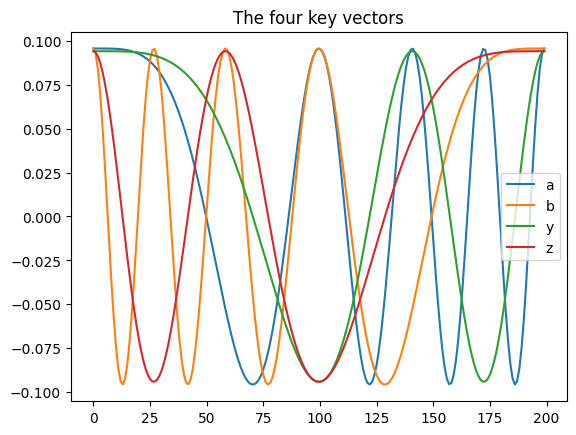

In [84]:
plt.plot(x,a)
plt.plot(x,b)
plt.plot(x,y)
plt.plot(x,z)
plt.legend(['a','b','y','z'])
plt.title('The four key vectors')
plt.show()

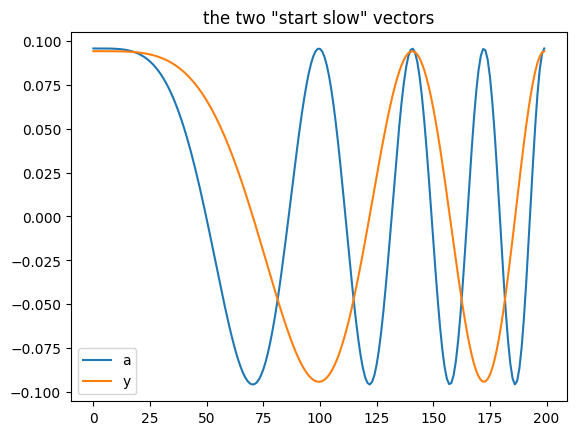

In [85]:
plt.plot(x,a)
plt.plot(x,y)
plt.title('the two "start slow" vectors')
plt.legend(['a','y'])
plt.show()

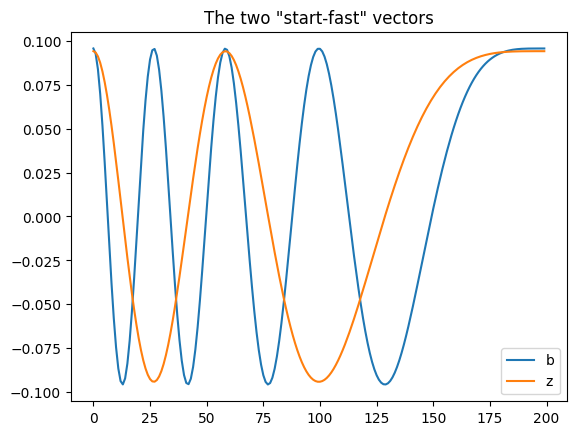

In [86]:
plt.plot(x,b)
plt.plot(x,z)
plt.title('The two "start-fast" vectors')
plt.legend(['b','z'])
plt.show()

We will use these shapes throughout the notebook.  If you note what a, b, y, and z look like, it will be a little easier to understand the examples that follow below.

# Shapes tend to be kind of orthogonal with each other
Here, we compute the attention function, taking only the embeddings as inputs without any embedding function.

We also don't use a mask here.

In [87]:
E = torch.cat((a,b,y,z),dim=1).T
E.shape

torch.Size([4, 200])

In [88]:
def softmax(X,dim=1):
    M,_ = X.max(dim=dim,keepdims=True)
    X = X-M
    E = torch.exp(X)
    S = torch.sum(E,dim=dim,keepdims=True)
    P = E/S
    return P

In [89]:
A = softmax(E @ E.T)
A

tensor([[0.4546, 0.1980, 0.2163, 0.1311],
        [0.1980, 0.4546, 0.1311, 0.2163],
        [0.2139, 0.1296, 0.4496, 0.2069],
        [0.1296, 0.2139, 0.2069, 0.4496]])

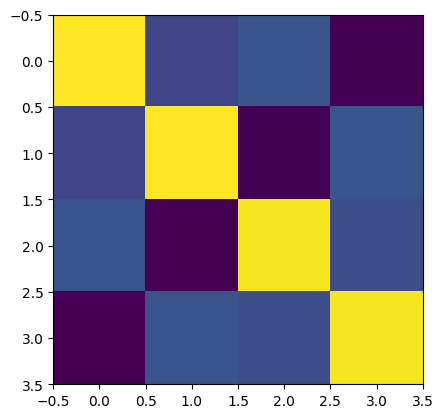

In [90]:
plt.imshow(A)

TODO: what can you see in the attention matrix A above that shows that each of our embedding "shapes" is roughly orthogonal to each other?

# A matrix can store an arbitrary key-value mapping

Here, we define a linear mapping `Q = E @ W`, defining `W` so that when the embedding `b` comes in, the output will have the shape of the key `z`

In [91]:
W = b @ z.T

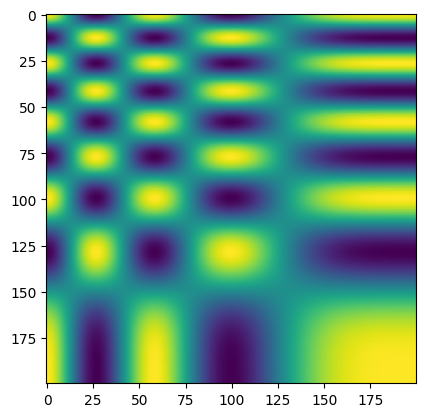

In [92]:
plt.imshow(W)

Note how W looks like z along its rows and like b along its columns. This is a result of W simply being the outer product b @ z.T

In [93]:
Q = E @ W
Q.shape

torch.Size([4, 200])

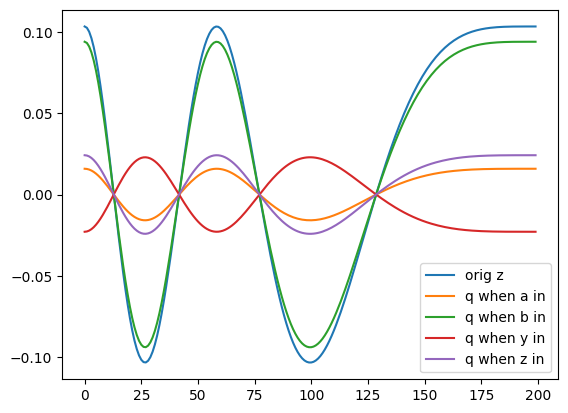

In [94]:
plt.plot(x, torch.cat((z*1.1,Q.T),dim=1))
plt.legend(['orig z','q when a in','q when b in','q when y in','q when z in'])
plt.show()

Notice that when `b` comes in, the output embedding `q` is closest to the original `z`, just as we set up `W` to achieve.  When the other curves come in, they also have the shape of `z`, but their output amplitude is smaller.

TODO: Why does q always have the same shape as z?

TODO: Why is the amplitude strongest when b comes into the Q = E @ W transform?

In [95]:
# TODO: Make a mapping that maps an input embedding of a to an output embedding of q = y (approximately)
# W = # TODO
Q = E @ W
Q.shape

torch.Size([4, 200])

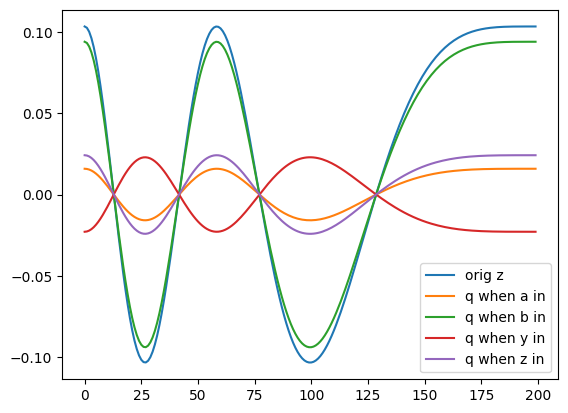

In [96]:
plt.plot(x, torch.cat((z*1.1,Q.T),dim=1))
plt.legend(['orig z','q when a in','q when b in','q when y in','q when z in'])
plt.show()

TODO: See the TODOs above.

# A matrix can store multiple key-value mappings

Here, we define the mapping so that one of two different inputs (keys) will map to two other arbitrary outputs (values)

In [127]:
W = b @ a.T + y @ z.T

This mapping maps b to a and y to z.

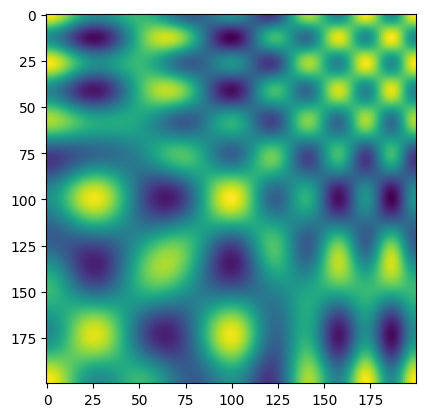

In [98]:
plt.imshow(W)

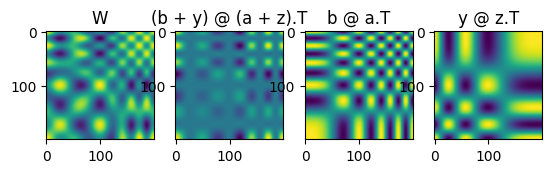

In [99]:
f, axarr = plt.subplots(1,4)
axarr[0].imshow(W)
axarr[1].imshow((b + y) @ (a + z).T)
axarr[2].imshow(b @ a.T)
axarr[3].imshow(y @ z.T)
axarr[0].set_title('W')
axarr[1].set_title('(b + y) @ (a + z).T')
axarr[2].set_title('b @ a.T')
axarr[3].set_title('y @ z.T')
plt.show()

Notice that `W` is no longer rank 1 and the rows and columns are no longer simply proportional to a single vector.  This is more apparent when we compare `W` with the rank-1 matrix `(b + y) @ (a + z).T`.

Instead, `W` encodes two key-value pairs superimposed on one another.  We test this below.

In [100]:
Q = E @ W

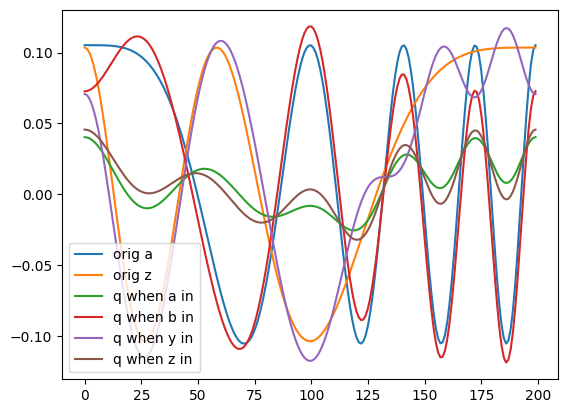

In [101]:
plt.plot(x, torch.cat((a*1.1,z*1.1,Q.T),dim=1))
plt.legend(['orig a','orig z','q when a in','q when b in','q when y in','q when z in'])
plt.show()

Notice how when the input embedding is b or y, the output of the network `q` is closest to the original a or z embeddings (`orig a` or `orig z`), just as we set up `W` to perform.

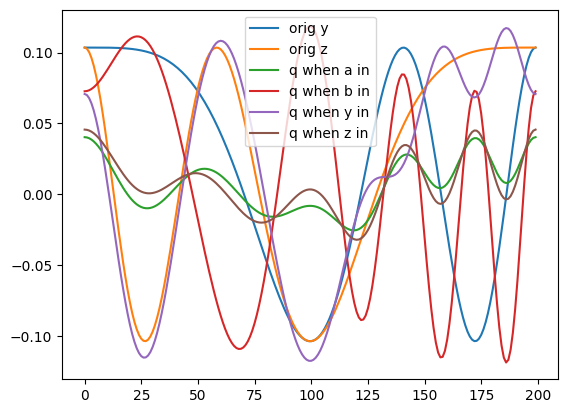

In [128]:
# TODO: Make your own mapping that maps a to y and b to z
# W = # TODO
Q = E @ W
plt.plot(x, torch.cat((y*1.1,z*1.1,Q.T),dim=1))
plt.legend(['orig y','orig z','q when a in','q when b in','q when y in','q when z in'])
plt.show()

TODO: Does the figure show that your mapping works?

# We can get different keys and values to match by transforming them to the same embedding
If we define two mappings, $W^Q$ and $W^K$, we can get two different embeddings to match each other in attention.

In [102]:
Wq = a @ c.T + torch.eye(E.shape[1])
Wk = b @ c.T + torch.eye(E.shape[1])

These embeddings are designed to both map to a new embedding (`c`), which was defined at the beginning, but which we haven't used anywhere yet.  But each embedding keys onto a different input vector, `a` or `b`.

By mapping input embeddings to an embedding that is not in our vocabulary, we can ensure that we won't accidentally map to a different term.

This is especially important because we use the `torch.eye(E.shape[1])` term (an identity matrix) so that embeddings which do not match the key still have some embedding value and will match themselves more strongly than other tokens.  This seems to be similar to how the embeddings in the original [*Attention Is All You Need* paper](https://arxiv.org/abs/1706.03762) behave. See Figures 4 and 5 on the last pages of the paper, where many tokens attend only to themselves, shown as perfectly horizontal lines in the figures.  Having Q and K embeddings that act like the identity function encourage this behavior.

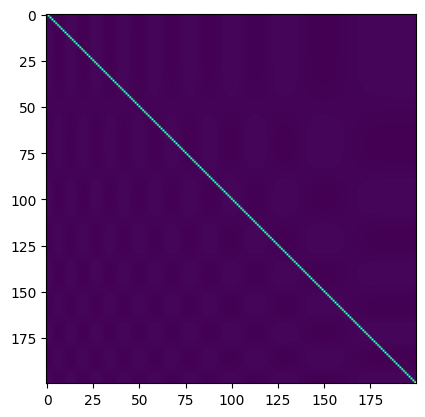

In [103]:
plt.imshow(Wq)

The identity function dominates this mapping, butyou can still see the faint patterns in the background which hold the key-value mapping content of this linear layer.  Even though they are faint, because they are present in nearly every element, they have an effect that is just as strong as the identity matrix when multiplied by a vector.

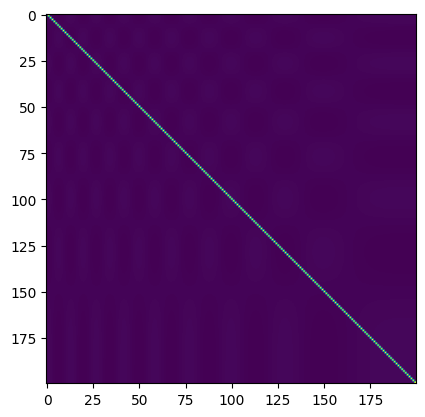

In [104]:
plt.imshow(Wk)

ditto what we said above.

In [130]:
Q = E @ Wq

In [131]:
K = E @ Wk

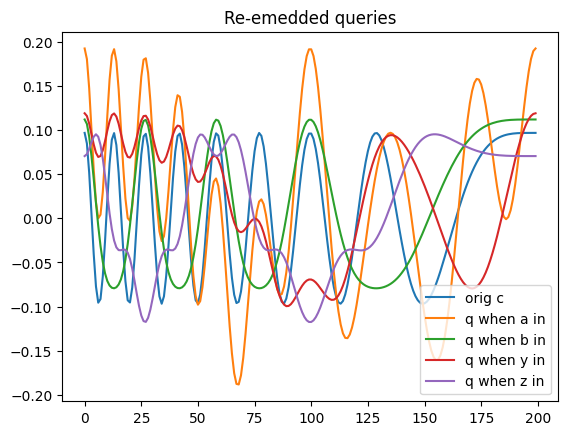

In [132]:
plt.plot(x, torch.cat((c,Q.T),dim=1))
plt.title('Re-emedded queries')
plt.legend(['orig c','q when a in','q when b in','q when y in','q when z in'])
plt.show()

Note that the original `c` embedding comes out most strongly when `a` is coming in (although `a` comes out just as strongly as `c` due to the identity matrix component in Wq)

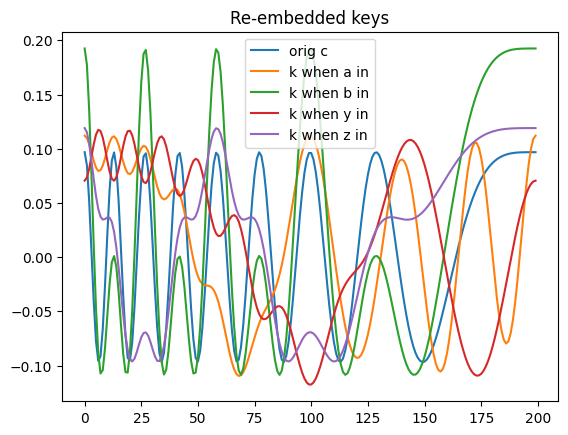

In [133]:
plt.plot(x, torch.cat((c,K.T),dim=1))
plt.title('Re-embedded keys')
plt.legend(['orig c','k when a in','k when b in','k when y in','k when z in'])
plt.show()

And again, if you look closely, you will see that when b come in, `q` has the high-frequency shapes that the original `c` embedding has (`orig c`), although it also has its own shapes `b` added on top of that.

Now we compute the attention. First we compute lin_A (the linear input to softmax when computing A):

In [136]:
lin_A = Q @ K.T
lin_A

tensor([[ 1.2354,  1.4163, -0.0249,  0.2012],
        [ 0.2389,  1.3913, -0.3355,  0.3788],
        [ 0.3112,  0.0380,  0.9370,  0.3284],
        [-0.2696,  0.1401,  0.2472,  0.9396]])

In [137]:
A = softmax(lin_A)
A

tensor([[0.3524, 0.4223, 0.0999, 0.1253],
        [0.1701, 0.5385, 0.0958, 0.1956],
        [0.2151, 0.1637, 0.4023, 0.2189],
        [0.1327, 0.1999, 0.2225, 0.4448]])

# TODO:
What elements in the matrix above causes token a to attend to token b's embedding?  

(Note that we are NOT using a causal mask here!)

# Blending embeddings
And now we can blend the embeddings.

In [111]:
attention = A @ E

Here, `attention` is the output of the attention head, `A`, is the attention matrix, and `E` are the embeddings going into the attention head (we aren't using a value embeeding $W^V$ like in real multi-head attention).

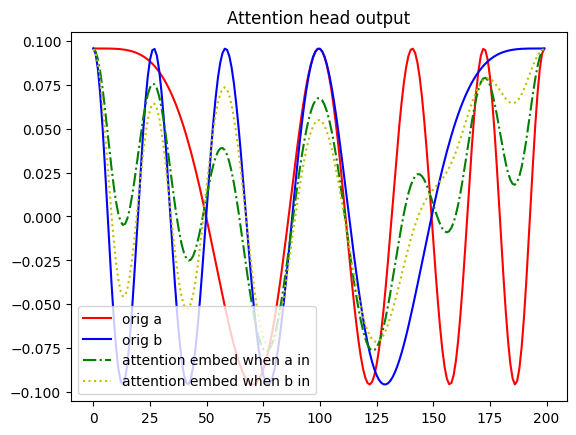

In [138]:
fig, ax = plt.subplots(ncols=1, nrows=1)
ax.set_prop_cycle(
    color=list('rbgy'),
    linestyle= ['-', '-', '-.', ':']
)
plt.title('Attention head output')
plt.plot(x, torch.cat((a,b,attention[0:2,:].T),dim=1))
plt.legend(['orig a','orig b','attention embed when a in','attention embed when b in'])
plt.show()

This illustrates the blending process within an attention head.  Note that the outputs are each linear combinations of all the embeddings going into the attention head.  The attention head's output is just a linear combination of the various embeddings coming in. Each embedding looks the most like the embeddings that had the most weight coming in.

TODO: Do you see the `c` embedding blended in above?

If so, how does it get in?

If not, why does it not get blended in?

# Another look at attention

We again compute `A` as before.

In [140]:
A = softmax(lin_A)
A

tensor([[0.3524, 0.4223, 0.0999, 0.1253],
        [0.1701, 0.5385, 0.0958, 0.1956],
        [0.2151, 0.1637, 0.4023, 0.2189],
        [0.1327, 0.1999, 0.2225, 0.4448]])

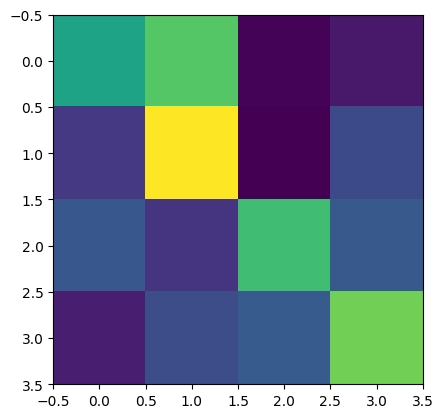

In [141]:
plt.imshow(A)

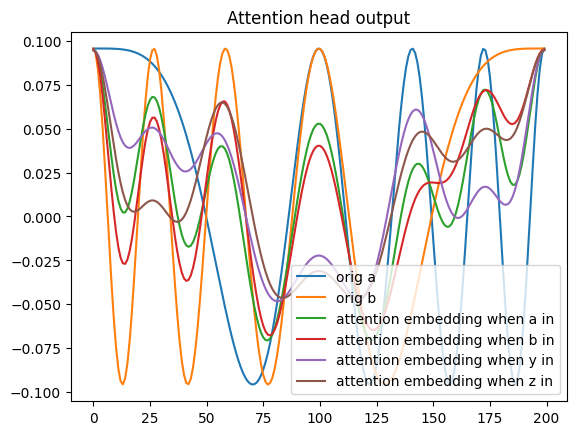

In [143]:
attention = A @ E
plt.plot(x, torch.cat((a,b,attention.T),dim=1))
plt.title('Attention head output')
plt.legend(['orig a','orig b','attention embedding when a in','attention embedding when b in','attention embedding when y in','attention embedding when z in'])
plt.show()

Here we can see that when a and b come in (in the legend, `a in` and `b in`), the output curves are closest to the original b embeddin (`orig b`). This is how we designed the attention operation to operate through the `Wq` and `Wk` we used in this example.

Notice that the embeddings do NOT inlude the `c` embedding anymore. That embedding was only used in `Wq` and `Wk`, which impacted the attention matrix and caused `a` to attend to `b`, but don't change either the embedding of `a` or `b` to include `c` in the output of the head shown here.

# Simpler numeric example

Here, we look at a simple numeric example with two small vectors to see how W = c @ a.T becomes a key-value mapping where we can see how each number is computed one element at a time.

In [116]:
a_small = torch.tensor([[1,-0.5,0.5,-1]]).T
a_small

tensor([[ 1.0000],
        [-0.5000],
        [ 0.5000],
        [-1.0000]])

In [117]:
c_small = torch.tensor([[1,1,-1,-1.0]]).T
c_small

tensor([[ 1.],
        [ 1.],
        [-1.],
        [-1.]])

Notice that c.T @ c gives us the length of c squared: (it's always positive)

In [118]:
(c_small.T @ c_small)

tensor([[4.]])

Now we define the W that maps c rows to a rows:

In [119]:
W = c_small @ a_small.T
W

tensor([[ 1.0000, -0.5000,  0.5000, -1.0000],
        [ 1.0000, -0.5000,  0.5000, -1.0000],
        [-1.0000,  0.5000, -0.5000,  1.0000],
        [-1.0000,  0.5000, -0.5000,  1.0000]])

In [120]:
c_small.T @ W

tensor([[ 4., -2.,  2., -4.]])

Substituting W = (c @ a.T) into the above, we can see this is the same as:

In [121]:
c_small.T @ (c_small @ a_small.T)

tensor([[ 4., -2.,  2., -4.]])

Now, because matrix multiplications commute, this is the same as:

In [122]:
(c_small.T @ c_small) @ a_small.T

tensor([[ 4., -2.,  2., -4.]])

And because (c.T @ c) is just the scalar 4, this is the same as

In [123]:
4 * a_small.T

tensor([[ 4., -2.,  2., -4.]])